In [8]:
import pandas as pd


In [9]:
customer = pd.read_csv("../data/Mall_Customers.csv")

customer.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [10]:
print(customer.shape)
print("\n \n")
print(customer.dtypes)
print("\n \n")
print(customer.describe())
print("\n \n")
customer.isnull().sum()

(200, 5)

 

CustomerID                int64
Gender                      str
Age                       int64
Annual Income (k$)        int64
Spending Score (1-100)    int64
dtype: object

 

       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000

 



CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

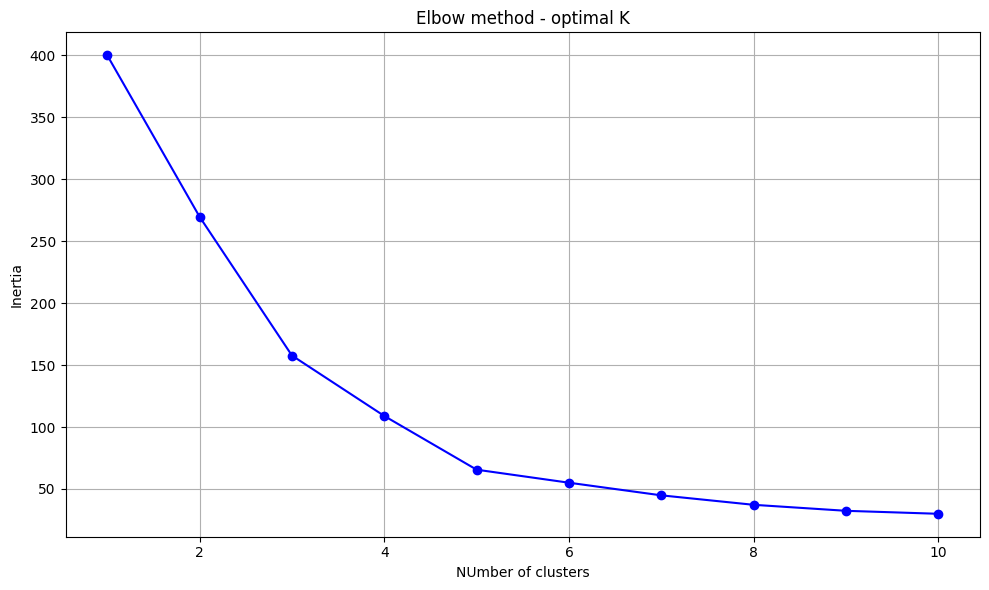

In [11]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

X = customer[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Elbow Method
inertia =[]
K_range = range(1,11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, "bo-")
plt.xlabel("NUmber of clusters")
plt.ylabel("Inertia")
plt.title("Elbow method - optimal K")
plt.grid(True)
plt.savefig('../plots/elow_curve.png')
plt.tight_layout()
plt.show()

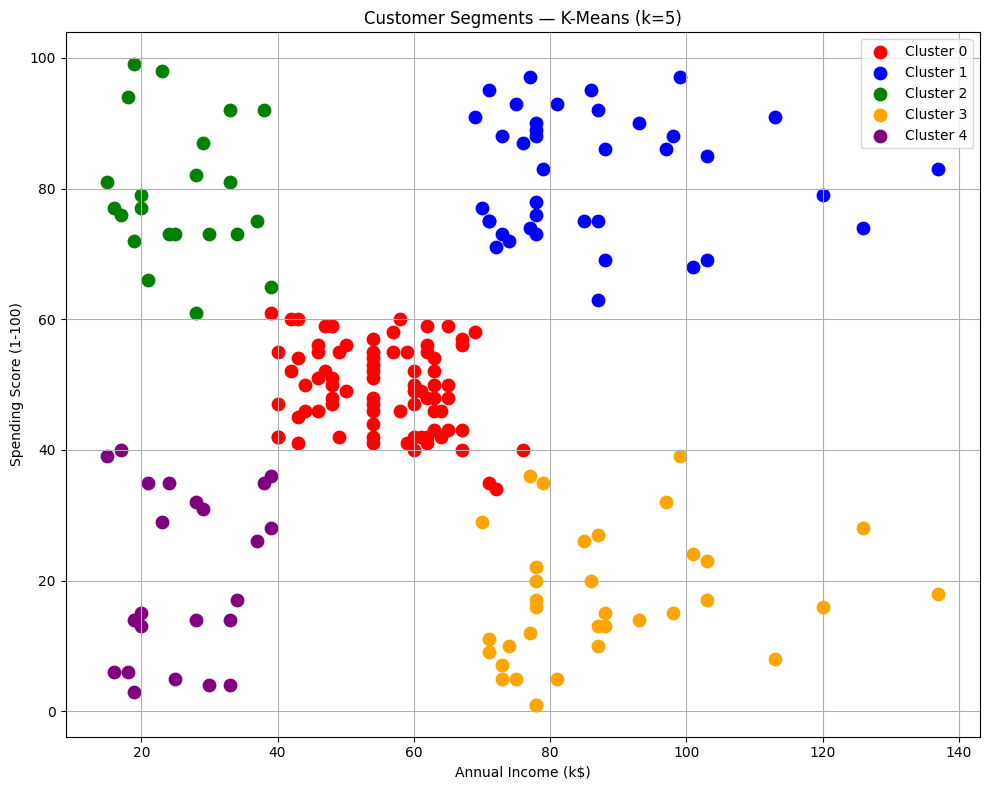

In [12]:
km = KMeans(n_clusters=5, random_state=42, n_init=10)
customer['Cluster'] = km.fit_predict(X_scaled)

plt.figure(figsize=(10, 8))
colors = ['red', 'blue', 'green', 'orange', 'purple']
for i in range(5):
    cluster_data = customer[customer['Cluster'] == i]
    plt.scatter(cluster_data['Annual Income (k$)'],
                cluster_data['Spending Score (1-100)'],
                c=colors[i], label=f'Cluster {i}', s=80)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments — K-Means (k=5)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('../plots/clusters.png')
plt.show()

In [36]:
profile = customer.groupby(["Cluster"])[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
print(profile)

          Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                  
0        42.7                55.3                    49.5
1        32.7                86.5                    82.1
2        25.3                25.7                    79.4
3        41.1                88.2                    17.1
4        45.2                26.3                    20.9
